# Automated Road Damage Classification Using Deep Learning and Cloud Deployment

## 02 - Data Preprocessing

### Objective
To prepare road damage images for deep learning by resizing,
normalizing and augmenting the training images.

We use separate notebooks for each major stage of the project. This keeps the project clean, organized and easy to explain during the final evaluation.

In [1]:
# Import os to work with folders and file paths
import os

# Import numpy for numerical operations
import numpy as np

# Import matplotlib to display images
import matplotlib.pyplot as plt

# Import TensorFlow for deep learning
import tensorflow as tf

# Display the TensorFlow version
# This helps us know which version is being used for the project
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Get the current working directory
# This tells Python where our notebook is running
current_path = os.getcwd()

# Set the path of our final dataset
# This dataset contains train, validation and test folders
dataset_path = os.path.join(
    current_path,
    "Automated_Road_Damage_Classification",
    "dataset"
)

# Define the paths for each dataset split
train_path = os.path.join(dataset_path, "train")
validation_path = os.path.join(dataset_path, "validation")
test_path = os.path.join(dataset_path, "test")

# Display the dataset paths
print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

Train path: C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\train
Validation path: C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\validation
Test path: C:\Users\Gopal\Automated_Road_Damage_Classification\dataset\test


In [3]:
# Check whether all dataset folders exist
# This prevents path-related errors before we start preprocessing

print("Train folder exists:", os.path.exists(train_path))
print("Validation folder exists:", os.path.exists(validation_path))
print("Test folder exists:", os.path.exists(test_path))

Train folder exists: True
Validation folder exists: True
Test folder exists: True


In [4]:
# Set the image size required by our deep learning model
# All images will be resized to 224 x 224 pixels
image_size = (224, 224)

# Set the number of images processed at one time
# A smaller batch size helps reduce memory usage
batch_size = 32

# Define our three road damage classes
# The model will learn to classify images into these three categories
class_names = ["pothole", "crack", "manhole"]

print("Image size:", image_size)
print("Batch size:", batch_size)
print("Classes:", class_names)

Image size: (224, 224)
Batch size: 32
Classes: ['pothole', 'crack', 'manhole']


In [5]:
# Load the training images from the train folder
# TensorFlow automatically assigns labels based on the folder names
# Images are resized to 224 x 224 pixels

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=True,
    seed=42
)

print("Training dataset loaded successfully!")

Found 702 files belonging to 3 classes.
Training dataset loaded successfully!


In [6]:
# Load the validation images
# Validation data is used to check model performance during training
# We do not use validation images to train the model

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

print("Validation dataset loaded successfully!")

Found 173 files belonging to 3 classes.
Validation dataset loaded successfully!


# Load the test images
# Test data is used only after training to measure final model performance

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

print("Test dataset loaded successfully!")

We resize all images to the same size because deep learning models need a fixed input size. We also organize the images into three classes so TensorFlow can automatically assign the correct labels.

In [8]:
# Normalize image pixel values
# Original pixel values are between 0 and 255
# We convert them to a smaller range between 0 and 1
# This helps the deep learning model learn more effectively

normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)

print("Normalization layer created successfully!")

Normalization layer created successfully!


Images normally contain pixel values from 0 to 255. We convert them to 0 to 1 so the model can process the image data more easily.

In [10]:
# Create data augmentation for training images
# Augmentation creates slightly different versions of images
# This helps the model handle real-world changes in road images

data_augmentation = tf.keras.Sequential([
    
    # Randomly flip the image horizontally
    # This helps the model learn from different image orientations
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate the image slightly
    # This makes the model more robust to different camera angles
    tf.keras.layers.RandomRotation(0.1),

    # Randomly change the image brightness
    # This helps the model handle different lighting conditions
    tf.keras.layers.RandomBrightness(
        factor=0.2
    ),

    # Randomly zoom into the image
    # This helps the model recognize damage at different distances
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


Real-world road images can have different angles, lighting and distances. Data augmentation creates variations of training images so the model can become more robust.

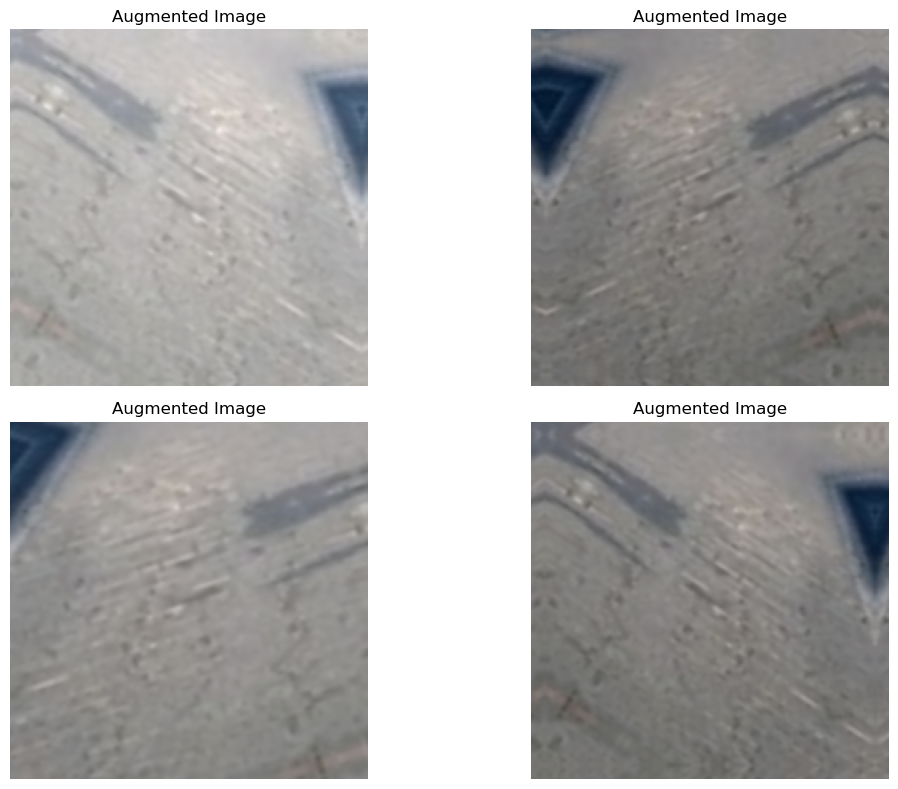

In [11]:
# Get one batch of training images
# We use this batch to visualize the augmentation process

for images, labels in train_dataset.take(1):
    sample_images = images
    sample_labels = labels
    break

# Select the first image from the batch
original_image = sample_images[0]

# Create multiple augmented versions of the same image
augmented_images = []

for i in range(4):
    
    # Apply augmentation to the image
    augmented_image = data_augmentation(
        tf.expand_dims(original_image, axis=0),
        training=True
    )

    # Store the augmented image
    augmented_images.append(
        augmented_image[0]
    )

# Display the augmented images
plt.figure(figsize=(12, 8))

for i, image in enumerate(augmented_images):

    plt.subplot(2, 2, i + 1)

    # Convert image values to displayable format
    plt.imshow(
        tf.cast(
            tf.clip_by_value(image, 0, 255),
            tf.uint8
        )
    )

    plt.axis("off")
    plt.title("Augmented Image")

plt.tight_layout()
plt.show()

In [12]:
# Import the class weight function
# Class weights help the model give more importance to smaller classes

from sklearn.utils.class_weight import compute_class_weight

In [14]:
# Count the number of training images in each class
# We use the actual training folders to calculate class weights

train_class_counts = {}

for class_name in class_names:

    # Create the path for the current class folder
    class_folder = os.path.join(train_path, class_name)

    # Count all image files in the class folder
    count = len([
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    # Store the image count
    train_class_counts[class_name] = count

print("Training class counts:")
print(train_class_counts)

Training class counts:
{'pothole': 234, 'crack': 401, 'manhole': 67}


In [15]:
# Calculate class weights to handle class imbalance
# Classes with fewer images will receive higher weights

total_training_images = sum(train_class_counts.values())
number_of_classes = len(class_names)

class_weights = {}

for class_id, class_name in enumerate(class_names):

    # Calculate the balanced class weight
    weight = total_training_images / (
        number_of_classes * train_class_counts[class_name]
    )

    class_weights[class_id] = weight

print("Class weights:")

Class weights:


In [16]:
# Display the class weights with readable class names
# This helps us understand the importance given to each class

for class_id, weight in class_weights.items():

    print(
        f"{class_names[class_id]}: {weight:.2f}"
    )

pothole: 1.00
crack: 0.58
manhole: 3.49


“We use class weights because our dataset is imbalanced. The Manhole class has fewer images, so we give it a higher weight during training.”